# Clustering Comparison: DBSCAN vs. K-Means

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is an
**unsupervised, density-based clustering** algorithm. Unlike K-Means, it does
not need the number of clusters `k` up front, can find **arbitrarily shaped**
clusters, and automatically labels sparse points as **noise/outliers**
(label `-1`).

In this notebook we build a non-globular ("moons") synthetic dataset with
injected noise and walk through:

1. Data Generation (moons + injected noise points)
2. Data Scaling
3. Choosing `eps` with the k-distance graph (elbow method)
4. Density-Based Clustering (DBSCAN) — clusters + noise highlighted
5. Centroid-Based Clustering (K-Means) on the *same* data
6. Side-by-side visual comparison: DBSCAN vs. K-Means
7. Evaluating cluster quality with the Silhouette Score
8. Key takeaways

> See `README.md` in this folder for the full theory: formulas, a hand-worked
> numeric example, pseudocode, hyperparameter guidance, and a deep comparison
> with K-Means.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
rng = np.random.RandomState(RANDOM_STATE)

## 1. Data Generation

We start with the classic **'moons' dataset** — two interlaced crescents.
This shape is the textbook example for showing off DBSCAN's strength: the
clusters are **not spherical/convex**, so a centroid-based method like
K-Means cannot separate them correctly no matter how it is tuned.

We then **inject a handful of scattered noise points** that don't belong to
either crescent. This simulates real-world outliers and lets us later verify
that DBSCAN correctly tags them with the noise label `-1`, instead of forcing
them into a cluster (which K-Means would have to do).

Total points: 315  (moons: 300, injected noise: 15)


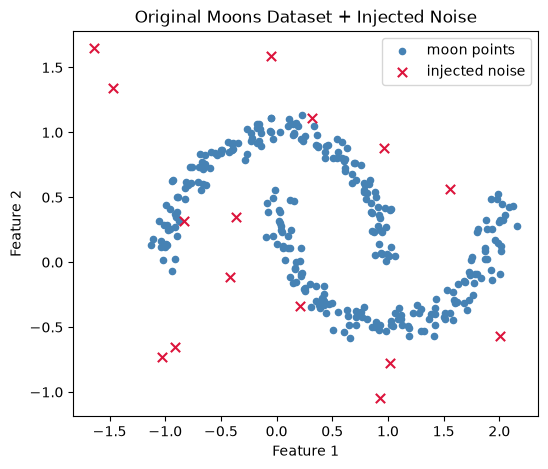

In [2]:
X_moons, _ = make_moons(n_samples=300, noise=0.06, random_state=RANDOM_STATE)

# Inject points uniformly scattered around the bounding box of the moons.
# These do not belong to either crescent -> they should end up as DBSCAN noise.
n_noise_pts = 15
noise_pts = rng.uniform(
    low=X_moons.min(axis=0) - 0.6,
    high=X_moons.max(axis=0) + 0.6,
    size=(n_noise_pts, 2),
)

X = np.vstack([X_moons, noise_pts])
print(f"Total points: {X.shape[0]}  (moons: {X_moons.shape[0]}, injected noise: {n_noise_pts})")

plt.figure(figsize=(6, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], s=20, color="steelblue", label="moon points")
plt.scatter(noise_pts[:, 0], noise_pts[:, 1], s=45, color="crimson", marker="x", label="injected noise")
plt.title("Original Moons Dataset + Injected Noise")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

## 2. Feature Scaling

Clustering algorithms rely on distance metrics (Euclidean distance for
DBSCAN's `eps`). If features have different scales, one feature dominates the
distance calculation and `eps` becomes meaningless across axes. We use
`StandardScaler` so every feature has mean 0 and standard deviation 1.

**This is a general rule for any density/distance-based clustering: always
scale first.**

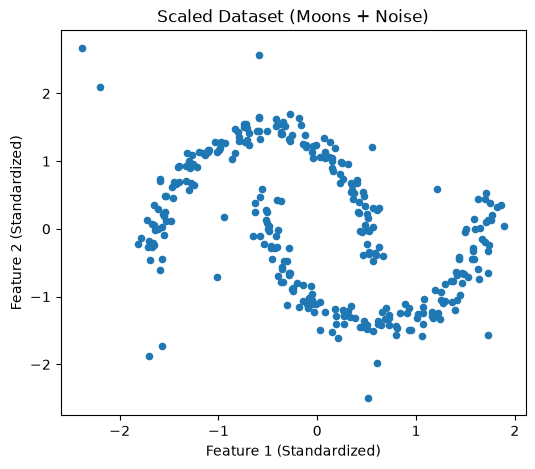

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=20)
plt.title("Scaled Dataset (Moons + Noise)")
plt.xlabel("Feature 1 (Standardized)")
plt.ylabel("Feature 2 (Standardized)")
plt.show()

## 3. Choosing `eps`: the k-distance Graph (Elbow Method)

`eps` and `min_samples` should not be guessed blindly. A principled way to
pick `eps` (for a fixed `min_samples = k`):

1. For every point, compute the distance to its **k-th nearest neighbor**
   (`k = min_samples`).
2. Sort these k-distances in **descending** order and plot them.
3. Points inside dense clusters have *small* k-distances (flat part of the
   curve on the right); noise/sparse points have *large* k-distances (steep
   part on the left).
4. The **"elbow"** — where the curve bends sharply — is a good estimate for
   `eps`: it separates "dense enough" points from sparse/noise points.

Here we use `min_samples = 4` (rule of thumb: `min_samples >= n_features + 1`;
for 2D data, small values like 3-6 are typical starting points).

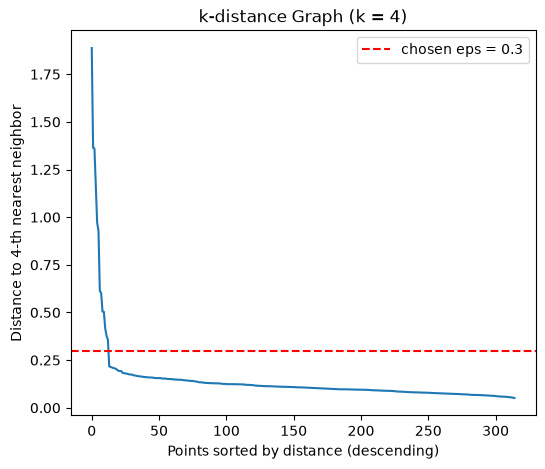

The steep drop on the left = noise/sparse points.
The elbow (where the curve flattens) is a good candidate for eps.
We pick eps = 0.3 based on the elbow above.


In [4]:
min_pts = 4  # will also be used as DBSCAN's min_samples below

neighbors = NearestNeighbors(n_neighbors=min_pts)
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)

# Distance to the k-th (last column) nearest neighbor, sorted descending.
k_distances = np.sort(distances[:, -1])[::-1]

chosen_eps = 0.3

plt.figure(figsize=(6, 5))
plt.plot(k_distances)
plt.axhline(y=chosen_eps, color="red", linestyle="--", label=f"chosen eps = {chosen_eps}")
plt.title(f"k-distance Graph (k = {min_pts})")
plt.xlabel("Points sorted by distance (descending)")
plt.ylabel(f"Distance to {min_pts}-th nearest neighbor")
plt.legend()
plt.show()

print("The steep drop on the left = noise/sparse points.")
print("The elbow (where the curve flattens) is a good candidate for eps.")
print(f"We pick eps = {chosen_eps} based on the elbow above.")

## 4. Density-Based Spatial Clustering (DBSCAN)

DBSCAN groups points that are closely packed together (dense regions) and
marks points in low-density regions as **noise** (label `-1`). It doesn't
assume clusters are spherical, so it handles the moons shape correctly.

We use the `eps` chosen from the k-distance elbow above, and
`min_samples = 4` (same `k` used to build that graph).

In [5]:
dbscan = DBSCAN(eps=chosen_eps, min_samples=min_pts)
dbscan.fit(X_scaled)

label_dbscan = dbscan.labels_

n_clusters_dbscan = len(set(label_dbscan)) - (1 if -1 in label_dbscan else 0)
n_noise_dbscan = list(label_dbscan).count(-1)

print(f"DBSCAN found {n_clusters_dbscan} clusters and {n_noise_dbscan} noise points.")

DBSCAN found 2 clusters and 12 noise points.


### Visualizing DBSCAN Results — Clusters *and* Noise

Noise points (`label == -1`) are plotted separately with a distinct
black `x` marker so they are never confused with a real cluster.

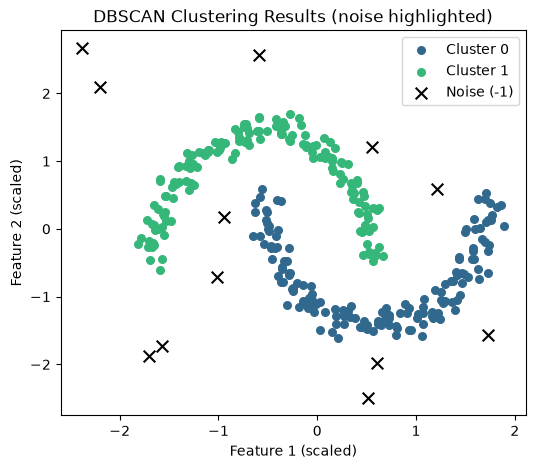

In [6]:
def plot_dbscan_result(ax, X_data, labels, title):
    unique_labels = sorted(set(labels))
    real_clusters = [l for l in unique_labels if l != -1]
    palette = sns.color_palette("viridis", max(len(real_clusters), 1))

    for i, lbl in enumerate(real_clusters):
        mask = labels == lbl
        ax.scatter(X_data[mask, 0], X_data[mask, 1], s=30, color=palette[i],
                   marker="o", label=f"Cluster {lbl}")

    if -1 in unique_labels:
        mask = labels == -1
        ax.scatter(X_data[mask, 0], X_data[mask, 1], s=70, color="black",
                   marker="x", linewidths=1.5, label="Noise (-1)")

    ax.set_title(title)
    ax.set_xlabel("Feature 1 (scaled)")
    ax.set_ylabel("Feature 2 (scaled)")
    ax.legend()


fig, ax = plt.subplots(figsize=(6, 5))
plot_dbscan_result(ax, X_scaled, label_dbscan, "DBSCAN Clustering Results (noise highlighted)")
plt.show()

## 5. K-Means Clustering on the *Same* Data

Now let's cluster the exact same scaled data with K-Means, forcing
`n_clusters=2` (giving it the "correct" number of clusters — an advantage
DBSCAN doesn't even need). K-Means tries to partition the data into `K`
clusters by minimizing distance between points and their centroids. Since it
assumes roughly spherical/convex clusters, watch how it **cuts across the two
crescents with a near-straight boundary** instead of following their true
shape — and it has no concept of noise, so every injected outlier gets forced
into one of the two clusters.

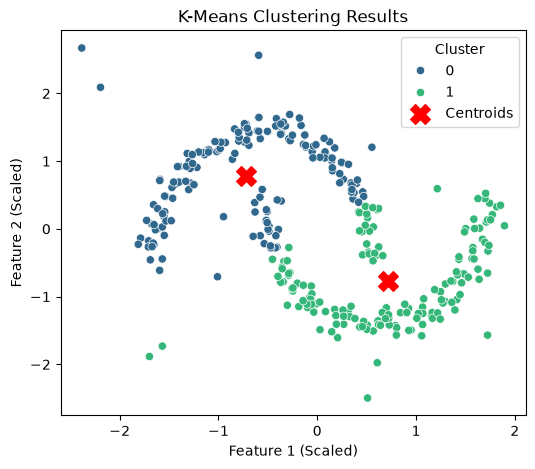

In [7]:
kmeans = KMeans(
    n_clusters=2,
    init="k-means++",
    max_iter=300,
    random_state=RANDOM_STATE,
)
kmeans.fit(X_scaled)
label_kmeans = kmeans.labels_

fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=label_kmeans, palette="viridis", ax=ax)
ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
           s=200, c="red", marker="X", label="Centroids")
ax.set_title("K-Means Clustering Results")
ax.set_xlabel("Feature 1 (Scaled)")
ax.set_ylabel("Feature 2 (Scaled)")
ax.legend(title="Cluster")
plt.show()

## 6. Side-by-Side Comparison: DBSCAN vs. K-Means

Same dataset, same scale, plotted next to each other. DBSCAN correctly
recovers the two crescent-shaped clusters and flags outliers as noise;
K-Means — constrained to convex/spherical partitions — slices the space with
a roughly linear boundary that cuts through both crescents and swallows the
noise points into whichever cluster is nearest.

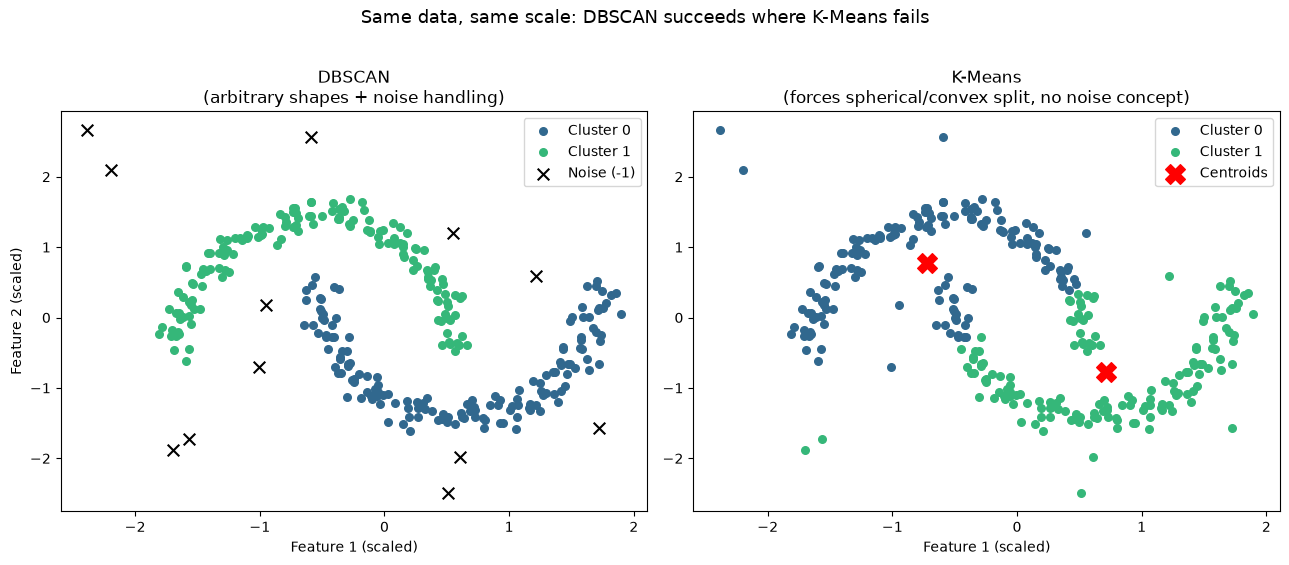

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

plot_dbscan_result(axes[0], X_scaled, label_dbscan, "DBSCAN\n(arbitrary shapes + noise handling)")

palette_km = sns.color_palette("viridis", 2)
for lbl in sorted(set(label_kmeans)):
    mask = label_kmeans == lbl
    axes[1].scatter(X_scaled[mask, 0], X_scaled[mask, 1], s=30, color=palette_km[lbl], label=f"Cluster {lbl}")
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                s=200, c="red", marker="X", label="Centroids")
axes[1].set_title("K-Means\n(forces spherical/convex split, no noise concept)")
axes[1].set_xlabel("Feature 1 (scaled)")
axes[1].legend()

fig.suptitle("Same data, same scale: DBSCAN succeeds where K-Means fails", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 7. Evaluating Cluster Quality: Silhouette Score

The **silhouette score** measures how well-separated and compact clusters
are, using only the data + labels (no ground truth needed) — see the README
for the formula. For DBSCAN we **exclude noise points** before scoring, since
`-1` is not a real cluster.

> **Caveat to remember:** silhouette score rewards compact, convex, well
> separated clusters. It can actually score K-Means *higher* than DBSCAN even
> when DBSCAN found the geometrically "correct" clusters and K-Means didn't —
> because silhouette has no idea what the *true* shape of the data is. Don't
> treat it as absolute truth; use it alongside a visual check.

In [9]:
# --- DBSCAN: score only the non-noise points ---
core_mask = label_dbscan != -1
sil_dbscan = silhouette_score(X_scaled[core_mask], label_dbscan[core_mask])
print(f"Silhouette score (DBSCAN, noise excluded): {sil_dbscan:.3f}")
print(f"  -> computed on {core_mask.sum()} of {len(label_dbscan)} points "
      f"({(~core_mask).sum()} noise points excluded)")

# --- K-Means: every point belongs to a cluster, so score all of them ---
sil_kmeans = silhouette_score(X_scaled, label_kmeans)
print(f"Silhouette score (K-Means, all points):        {sil_kmeans:.3f}")

Silhouette score (DBSCAN, noise excluded): 0.383
  -> computed on 303 of 315 points (12 noise points excluded)
Silhouette score (K-Means, all points):        0.482


## 8. Key Takeaways

- DBSCAN is **unsupervised clustering** — there is no "DBSCAN classifier" or
  "DBSCAN regressor"; it has no labels to predict, only density structure to
  discover. Its output (a cluster id, or `-1` for noise) can be *reused* as an
  engineered feature for a downstream supervised model, but DBSCAN itself
  does not predict any known target.
- No need to pre-specify the number of clusters (`k`) — DBSCAN only needs
  `eps` and `min_samples`.
- It found the correct crescent-shaped clusters that K-Means — constrained to
  convex/spherical partitions — could not.
- It explicitly separates out noise (`-1`), while K-Means is forced to assign
  every single point (including outliers) to some cluster.
- The k-distance graph gives a principled, repeatable way to choose `eps`
  instead of guessing.
- Silhouette score is a useful *relative* sanity check, but it is not aware
  of the true geometry of the data — always pair it with a visual inspection.

Full theory (math, hand-worked numeric example, pseudocode, hyperparameter
table, pitfalls, and a deep comparison with K-Means) is in `README.md` in
this same folder.